In [ ]:
#!/usr/bin/env python3
"""
Download ERA5 pressure-level data from cloud-hosted Zarr,
compute UTC daily means locally, and save monthly NetCDFs.

Modes
-----
Test one month:
    python download_era5_cloud_daily_means.py test --year 1980 --month 1

Run all months:
    python download_era5_cloud_daily_means.py full

Optional custom range:
    python download_era5_cloud_daily_means.py full --start-year 1980 --end-year 2024
"""

from __future__ import annotations

import argparse
import calendar
from pathlib import Path

import xarray as xr

# =========================
# User settings
# =========================
DEFAULT_START_YEAR = 1980
DEFAULT_END_YEAR = 2024

LAT_MAX = 39
LAT_MIN = 5
LON_MIN = 29
LON_MAX = 65

OUT_ROOT = Path("../data/era5")
SKIP_EXISTING = True

ZARR_URL = "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr"

# Output name -> (cloud short name, pressure level)
SPECS = {
    "geopotential": ("z", 500),
    "vertical_velocity": ("w", 500),
    "specific_humidity": ("q", 925),
    "u_component_of_wind": ("u", 925),
    "v_component_of_wind": ("v", 925),
}

CLOUD_VARS = sorted({v for v, _ in SPECS.values()})
LEVELS = sorted({lev for _, lev in SPECS.values()})


# =========================
# Helpers
# =========================
def open_cloud_dataset() -> xr.Dataset:
    """Open the remote Zarr lazily."""
    ds = xr.open_dataset(
        ZARR_URL,
        engine="zarr",
        chunks="auto",
        storage_options={"client_kwargs": {"trust_env": True}},
    )

    # Normalize time coord if needed
    if "valid_time" in ds.coords and "time" not in ds.coords:
        ds = ds.rename({"valid_time": "time"})

    return ds


def get_coord_names(ds: xr.Dataset) -> tuple[str, str, str]:
    """Return coord names for level, latitude, longitude."""
    if "pressure_level" in ds.coords:
        level_coord = "pressure_level"
    elif "level" in ds.coords:
        level_coord = "level"
    else:
        raise ValueError("Could not find pressure level coordinate.")

    if "latitude" in ds.coords:
        lat_coord = "latitude"
    elif "lat" in ds.coords:
        lat_coord = "lat"
    else:
        raise ValueError("Could not find latitude coordinate.")

    if "longitude" in ds.coords:
        lon_coord = "longitude"
    elif "lon" in ds.coords:
        lon_coord = "lon"
    else:
        raise ValueError("Could not find longitude coordinate.")

    return level_coord, lat_coord, lon_coord


def output_path(var_name: str, level: int, year: int, month: int) -> Path:
    out_dir = OUT_ROOT / var_name
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"{var_name}_{level}_{year}_{month:02d}.nc"


def month_output_paths(year: int, month: int) -> dict[str, Path]:
    return {
        name: output_path(name, level, year, month)
        for name, (_, level) in SPECS.items()
    }


def month_complete(year: int, month: int) -> bool:
    paths = month_output_paths(year, month)
    return all(p.exists() for p in paths.values())


def month_time_bounds(year: int, month: int) -> tuple[str, str]:
    ndays = calendar.monthrange(year, month)[1]
    start = f"{year}-{month:02d}-01T00:00:00"
    end = f"{year}-{month:02d}-{ndays:02d}T23:00:00"
    return start, end


def subset_month(ds: xr.Dataset, year: int, month: int) -> xr.Dataset:
    """
    Read only one month, the required variables, the required levels,
    and the AP spatial box.
    """
    start, end = month_time_bounds(year, month)
    level_coord, lat_coord, lon_coord = get_coord_names(ds)

    sub = ds[CLOUD_VARS].sel(time=slice(start, end))
    sub = sub.sel({level_coord: LEVELS})

    # Handle ascending vs descending latitude
    lat_vals = sub[lat_coord].values
    if lat_vals[0] > lat_vals[-1]:
        lat_slice = slice(LAT_MAX, LAT_MIN)
    else:
        lat_slice = slice(LAT_MIN, LAT_MAX)

    sub = sub.sel(
        {
            lat_coord: lat_slice,
            lon_coord: slice(LON_MIN, LON_MAX),
        }
    )

    return sub


def compute_daily_month(ds_month: xr.Dataset) -> xr.Dataset:
    """Compute UTC daily means from hourly data."""
    return ds_month.resample(time="1D").mean()


def save_month_outputs(daily: xr.Dataset, year: int, month: int) -> None:
    """Split one daily dataset into the 5 target NetCDF outputs."""
    level_coord, _, _ = get_coord_names(daily)

    for out_name, (cloud_var, level) in SPECS.items():
        out_path = output_path(out_name, level, year, month)

        if SKIP_EXISTING and out_path.exists():
            print(f"✓ exists, skipping file: {out_path}")
            continue

        da = daily[cloud_var].sel({level_coord: level}).rename(out_name)

        # Drop scalar pressure coord from final file if present
        if level_coord in da.coords:
            da = da.drop_vars(level_coord, errors="ignore")

        encoding = {
            out_name: {
                "zlib": True,
                "complevel": 4,
            }
        }

        da.to_netcdf(out_path, encoding=encoding)
        print(f"✓ saved: {out_path}")


def process_month(ds: xr.Dataset, year: int, month: int) -> None:
    """End-to-end processing for one month."""
    if SKIP_EXISTING and month_complete(year, month):
        print(f"✓ month complete, skipping {year}-{month:02d}")
        return

    print(f"\n=== Processing {year}-{month:02d} ===")
    ds_month = subset_month(ds, year, month)
    daily = compute_daily_month(ds_month)
    save_month_outputs(daily, year, month)


def run_test(year: int, month: int) -> None:
    """Run just one month as a benchmark/test."""
    print(f"Opening remote ERA5 Zarr for test run: {year}-{month:02d}")
    ds = open_cloud_dataset()
    process_month(ds, year, month)
    print("\nTest run complete.")


def run_full(start_year: int, end_year: int) -> None:
    """Run the full requested period."""
    print(f"Opening remote ERA5 Zarr for full run: {start_year} to {end_year}")
    ds = open_cloud_dataset()

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            process_month(ds, year, month)

    print("\nFull run complete.")


# =========================
# Main
# =========================
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Create monthly daily-mean ERA5 pressure-level files from cloud Zarr."
    )

    subparsers = parser.add_subparsers(dest="mode", required=True)

    p_test = subparsers.add_parser("test", help="Run one test month")
    p_test.add_argument("--year", type=int, required=True, help="Test year")
    p_test.add_argument("--month", type=int, required=True, help="Test month (1-12)")

    p_full = subparsers.add_parser("full", help="Run full period")
    p_full.add_argument(
        "--start-year",
        type=int,
        default=DEFAULT_START_YEAR,
        help=f"Start year (default: {DEFAULT_START_YEAR})",
    )
    p_full.add_argument(
        "--end-year",
        type=int,
        default=DEFAULT_END_YEAR,
        help=f"End year (default: {DEFAULT_END_YEAR})",
    )

    return parser.parse_args()


def main() -> None:
    args = parse_args()

    if args.mode == "test":
        if not (1 <= args.month <= 12):
            raise ValueError("Month must be between 1 and 12.")
        run_test(args.year, args.month)

    elif args.mode == "full":
        if args.start_year > args.end_year:
            raise ValueError("start-year must be <= end-year.")
        run_full(args.start_year, args.end_year)


if __name__ == "__main__":
    main()

In [27]:
import xarray as xr
import matplotlib.pyplot as plt

var = "specific_humidity"
height = "925"

path = f"../data/era5/{var}/{var}_{height}_2001_01.nc"

ds = xr.open_dataset(path)
print(ds)
ds

<xarray.Dataset> Size: 5MB
Dimensions:            (longitude: 145, latitude: 137, time: 31)
Coordinates:
  * longitude          (longitude) float32 580B 29.0 29.25 29.5 ... 64.75 65.0
  * latitude           (latitude) float32 548B 39.0 38.75 38.5 ... 5.5 5.25 5.0
  * time               (time) datetime64[ns] 248B 2001-01-01 ... 2001-01-31
Data variables:
    specific_humidity  (time, latitude, longitude) float64 5MB ...


<xarray.Dataset> Size: 5MB
Dimensions:            (longitude: 145, latitude: 137, time: 31)
Coordinates:
  * longitude          (longitude) float32 580B 29.0 29.25 29.5 ... 64.75 65.0
  * latitude           (latitude) float32 548B 39.0 38.75 38.5 ... 5.5 5.25 5.0
  * time               (time) datetime64[ns] 248B 2001-01-01 ... 2001-01-31
Data variables:
    specific_humidity  (time, latitude, longitude) float64 5MB ...

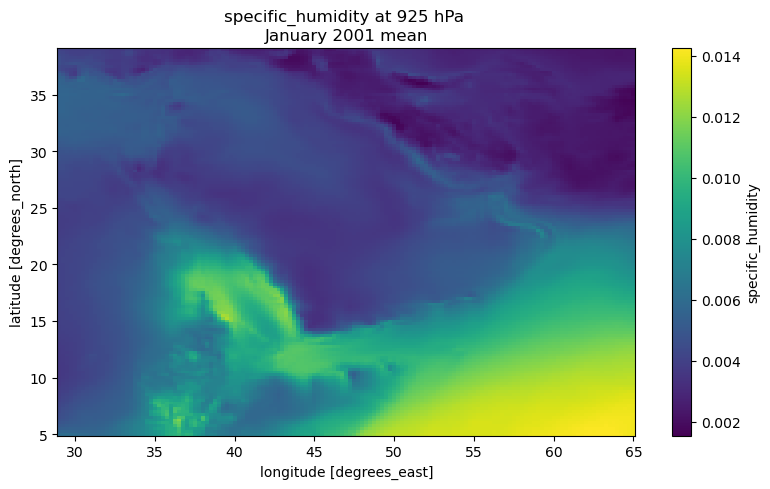

In [28]:
u = ds[f"{var}"]

plt.figure(figsize=(8, 5))
u.mean("time").plot()
plt.title(f"{var} at {height} hPa \nJanuary 2001 mean")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '500 hPa height daily variability — Jan 2000')

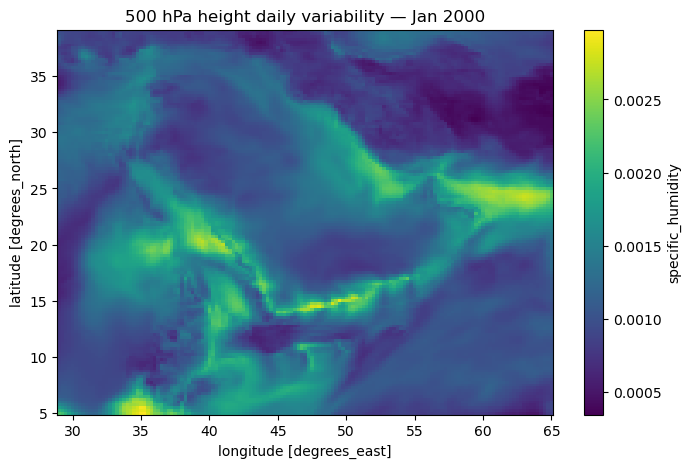

In [29]:
plt.figure(figsize=(8,5))
u.std("time").plot()
plt.title("500 hPa height daily variability — Jan 2000")